In [1]:
import matplotlib.pyplot as plt
import numpy as np

from centrex_tlf import couplings, hamiltonian, lindblad, states, transitions
import sympy as smp
from scipy.integrate import solve_ivp

plt.rcParams.update({"font.size": 14})

In [2]:
trans = transitions.R0_F1_1o2_F1
transition_selectors = couplings.generate_transition_selectors(
    transitions=[trans],
    polarizations=[[couplings.polarization_Z]],
    # ground_mains=[
    #     1.0
    #     * states.CoupledBasisState(
    #         J=0,
    #         F=1,
    #         F1=1 / 2,
    #         mF=0,
    #         I1=1 / 2,
    #         I2=1 / 2,
    #         P=+1,
    #         electronic_state=states.ElectronicState.X,
    #     )
    # ],
    # excited_mains=[
    #     1.0
    #     * states.CoupledBasisState(
    #         J=1,
    #         F=1,
    #         F1=1 / 2,
    #         mF=0,
    #         I1=1 / 2,
    #         I2=1 / 2,
    #         P=-1,
    #         Ω=1,
    #         electronic_state=states.ElectronicState.B,
    #     )
    # ],
)
system = lindblad.generate_OBE_system_transitions(
    [trans],
    transition_selectors,
    E=np.array([0.0, 0.0, 100.0]),
    qn_compact=True,
)

In [3]:
symbols = list(system.H_symbolic.free_symbols)
ham_lambdify = smp.lambdify(symbols, system.H_symbolic, modules="numpy", cse=True)

In [4]:
indexed_terms = system.dissipator.atoms(smp.Indexed)
bases = {term.base for term in indexed_terms}

if len(bases) != 1:
    raise ValueError(f"Expected 1 indexed base, got {bases}")

rho = next(iter(bases))

diss_lambdify = smp.lambdify(rho, system.dissipator, modules="numpy", cse=True)

In [5]:
def lindblad_rhs_vectorized(t, rho, ham, diss_func):
    rho = rho.reshape((ham.shape[0], ham.shape[1]))

    drho = diss_func(rho)  # or whatever your RHS is
    commutator = -1j * (ham @ rho - rho @ ham)
    return (commutator + drho).flatten()


In [6]:
values = {"Ω0": 2 * np.pi * 1e6, "PZ0": 1.0, "δ0": 0.0}
ham = ham_lambdify(**values)

rho0 = np.zeros((system.system.shape[0], system.system.shape[1]), dtype=complex)
rho0[0, 0] = 1.0


In [7]:
sol = solve_ivp(
    lindblad_rhs_vectorized,
    t_span=[0, 50e-6],
    y0=rho0.flatten(),
    args=(ham, diss_lambdify),
)

In [8]:
N = ham.shape[0]
rho_t = sol.y.T.reshape((-1, N, N))
pops = np.diagonal(rho_t, axis1=1, axis2=2).real

In [9]:
excited_selector = states.QuantumSelector(electronic=states.ElectronicState.B)
indices_excited = excited_selector.get_indices(system.QN)

In [10]:
system.QN

[1.00+0.00j x |X, J = 0, F₁ = 1/2, F = 0, mF = 0, I₁ = 1/2, I₂ = 1/2, P = +, Ω = 0>
 0.01+0.00j x |X, J = 1, F₁ = 3/2, F = 1, mF = 0, I₁ = 1/2, I₂ = 1/2, P = -, Ω = 0>
 -0.01+0.00j x |X, J = 1, F₁ = 1/2, F = 1, mF = 0, I₁ = 1/2, I₂ = 1/2, P = -, Ω = 0>,
 1.00-0.00j x |X, J = 0, F₁ = 1/2, F = 1, mF = -1, I₁ = 1/2, I₂ = 1/2, P = +, Ω = 0>
 0.01-0.00j x |X, J = 1, F₁ = 3/2, F = 2, mF = -1, I₁ = 1/2, I₂ = 1/2, P = -, Ω = 0>
 0.01-0.00j x |X, J = 1, F₁ = 1/2, F = 1, mF = -1, I₁ = 1/2, I₂ = 1/2, P = -, Ω = 0>
 0.00-0.00j x |X, J = 1, F₁ = 3/2, F = 1, mF = -1, I₁ = 1/2, I₂ = 1/2, P = -, Ω = 0>,
 1.00-0.00j x |X, J = 0, F₁ = 1/2, F = 1, mF = 0, I₁ = 1/2, I₂ = 1/2, P = +, Ω = 0>
 0.01-0.00j x |X, J = 1, F₁ = 3/2, F = 2, mF = 0, I₁ = 1/2, I₂ = 1/2, P = -, Ω = 0>
 -0.01+0.00j x |X, J = 1, F₁ = 1/2, F = 0, mF = 0, I₁ = 1/2, I₂ = 1/2, P = -, Ω = 0>,
 1.00+0.00j x |X, J = 0, F₁ = 1/2, F = 1, mF = 1, I₁ = 1/2, I₂ = 1/2, P = +, Ω = 0>
 0.01+0.00j x |X, J = 1, F₁ = 3/2, F = 2, mF = 1, I₁ = 1/2, I₂ = 1/

photons = 1.33


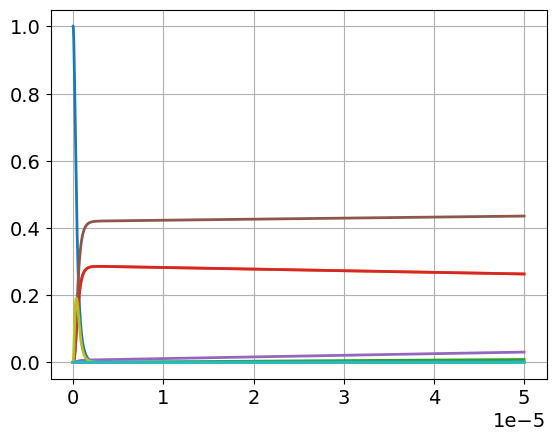

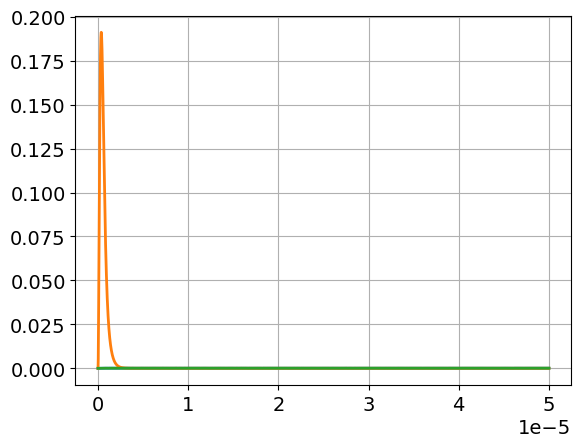

In [11]:
fig, ax = plt.subplots()
ax.plot(sol.t, pops, lw=2)
ax.grid()

fig, ax = plt.subplots()
ax.plot(sol.t, pops[:, indices_excited], lw=2)
ax.grid()

print(
    f"photons = {np.trapezoid(pops[:, indices_excited].sum(axis=1).real, x=sol.t) * hamiltonian.Γ:.2f}"
)

In [12]:
qn_B = states.QuantumSelector(
    J=[1, 2, 3], electronic=states.ElectronicState.B, Ω=[-1, 1]
)
states_B = states.generate_coupled_states_B(qn_B)
ham_B = hamiltonian.generate_coupled_hamiltonian_B(QN=states_B)
ham_B_func = hamiltonian.generate_coupled_hamiltonian_B_function(ham_B)

In [13]:
from scipy.optimize import linear_sum_assignment

Ez = np.linspace(0, 200, 501)

Hi = np.asarray(ham_B_func(E=[0.0, 0.0, 0.0], B=[0.0, 0.0, 1e-3]), dtype=np.complex128)
eigvals, eigvecs = np.linalg.eigh(Hi)

# get the true superposition-states of the system
QN_states = hamiltonian.matrix_to_states(eigvecs, QN=states_B)

# original eigenvectors used in tracking states as energies change order
V_track = eigvecs.copy()

# empty array for storing energies
energy = np.empty((Ez.size, len(states_B)), dtype=np.float64)

# iterate over the electric field values
for idx, Ei in enumerate(Ez):
    Hi = np.asarray(
        ham_B_func(E=[0.0, 0.0, float(Ei)], B=[0.0, 0.0, 1e-3]), dtype=np.complex128
    )
    eigvals, eigvecs = np.linalg.eigh(Hi)

    # sort indices to keep the state order the same
    overlap = np.abs(V_track.conj().T @ eigvecs)
    _, indices = linear_sum_assignment(-overlap)
    energy[idx, :] = eigvals[indices]
    V_track[:, :] = eigvecs[:, indices]


In [14]:
QN_states_parity = [qn.transform_to_parity_basis() for qn in QN_states]
qn_select = states.QuantumSelector(
    J=1, F1=1 / 2, F=[0, 1], electronic=states.ElectronicState.B, P=-1
)
indices_selected = qn_select.get_indices(QN_states_parity)

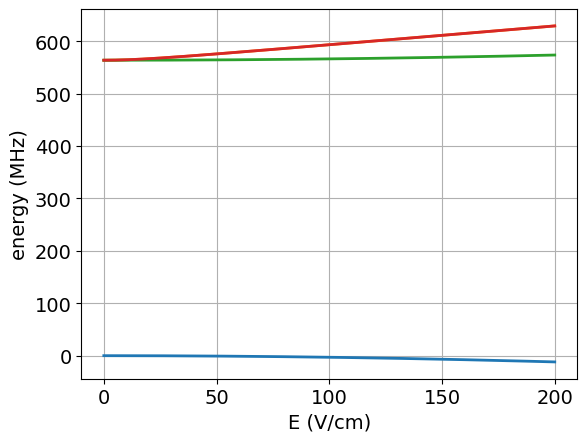

In [15]:
fig, ax = plt.subplots()
ax.plot(
    Ez,
    (energy[:, indices_selected] - energy[:, indices_selected][0, 0])
    / (2 * np.pi * 1e6),
    lw=2,
)
ax.set_xlabel("E (V/cm)")
ax.set_ylabel("energy (MHz)")
ax.grid()